In [100]:
from tripodpy import Simulation
import numpy as np
import matplotlib.pyplot as plt
import dustpy.constants as c

# Personalizacion de la fisica de un Field Existente

La idea es que gracias al snowline. $v_{frag}$ Depende de la temperatura del disco, es decir:

<div align="center">

$$
v_{frag} = 
\begin{cases}
10 \text{ m/s} & \text{si } T < 150 K\\
1 \text{ m/s} & \text{si } T > 150 K 
\end{cases}
$$

</div>


La idea es que las particulas recubiertas de hielo en hielo de agua son mas "adhesivo" que las particulas de silicato puro y por lo tanto soportan mayores velocidades de colision sin fragmentarse [Pinilla et al. (2017)](https://iopscience.iop.org/article/10.3847/1538-4357/aa7edb). Pero estudios mas recientes han descubierto que la envoltura de hielo presente en estas particulas no poseen un comportamiento beneficioso [ Musiolik & Wurm (2019)](https://iopscience.iop.org/article/10.3847/1538-4357/ab0428/pdf).

El paper de [ Musiolik & Wurm (2019)](https://iopscience.iop.org/article/10.3847/1538-4357/ab0428/pdf). sugiere que el mayor benificio se encuentra cerca de la snowline, pero que más alejado es menos efectivo, aproximadamente cae en un factor de ~30 al alejarse.

---
Anillos concentrados en snowlines? trampas de presion creadas de manera natural? reciclaje de polvo?

---

Varias preguntas se pueden venir a la cabeza, que podemos resolver más adelante, sigamos con la personalizaion del **Field**


In [ ]:
# Generamos nuestro objeto de Simulacion
sim = Simulation()

In [17]:
# Primero inicializamos nuestro objeto
sim.initialize()

Ahora, cada campo que es un Field puede ser modificable, en este caso que estamos analizando el snowline, asi que un factor clave seria modificar la velocidad de fragmentación en el disco. Tendriamos que hacer un filtro 

In [52]:
sim.dust.v.frag.updater


Heartbeat
---------

Systole:  None
Updater:  None
Diastole: None

Docstrings
----------

Systole:
None

Updater:
None

Diastole:
None

Notamos que el updater (actualizador en cada etapa de tiempo) esta vacio. Tenemos que tener en cuenta que v_frag tiene el mismo `.dust.v_frag.shape` que `.grid.Nr`, por lo que tenemos los datos de v_frag al centro de cada celda. Al principio v_frag es constante en todo el disco (100 cm/s o 1 m/s).

In [59]:
sim.dust.v.frag

[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100.]

La idea es hacer una funcion que tome nuestro objeto de simulacion y que nos de las velocidades de fragmetancion que queremos. Ya definimos arriba como deberia comportarse nuestro sistema. 

In [79]:
sim.gas.T

[217.49291969 210.10922624 202.97620269 196.08533903 189.42841412
 182.99748597 176.78488217 170.78319082 164.98525161 159.38414733
 153.97319563 148.74594098 143.69614703 138.81778914 134.10504722
 129.55229875 125.15411208 120.90523998 116.80061336 112.8353352
 109.00467475 105.30406186 101.72908152  98.27546862  94.93910285
  91.71600375  88.60232604  85.59435496  82.68850184  79.88129989
  77.16939997  74.54956667  72.01867441  69.57370372  67.21173763
  64.92995822  62.72564321  60.59616276  58.5389763   56.55162951
  54.63175139  52.77705145  50.98531695  49.25441025  47.58226632
  45.9668902   44.40635468  42.89879797  41.44242149  40.03548771
  38.67631809  37.36329109  36.0948402   34.8694521   33.68566485
  32.54206614  31.4372916   30.37002318  29.33898759  28.34295475
  27.38073635  26.45118442  25.55318996  24.68568162  23.84762443
  23.03801854  22.25589806  21.50032988  20.77041258  20.06527533
  19.38407687  18.7260045   18.09027311  17.47612424  16.88282518
  16.309668

In [80]:
def v_frag_updater(sim):
    return np.where(sim.gas.T<150., 1000., 100. )

In [81]:
sim.dust.v.frag.updater = v_frag_updater

In [83]:
sim.dust.v.frag.updater

Heartbeat
---------

Systole:  None
Updater:  <function v_frag_updater at 0x000001BA34822AC0>
Diastole: None

Docstrings
----------

Systole:
None

Updater:
None

Diastole:
None

Algunos problemas vienen con esto, simframe para la actualización de las componentes utiliza algo llamado Heartbeat, la analogia es la siguiente:

**Systole**: Proceso que se ejucta primero. (Como la contraccion del musculo del corazon)

**Updater**: El proceso o funcion misma. (Flujo de sangre)

**Diastole**: Proceso que se ejucta posteriomente al Updater. (relajacion de los musculos)

Cuando hacemos `.updater = func()` generamos un nuevo `Simframe.Heartbeat`, por lo que el `Systole` y `Diastole` se sobreescriben. Hay que tener mucho cuidado con esto para mas adelante para no romper nada y no generar bugs raros.

Lo siguiente solo se hara con fines de ilustración.

In [93]:
sim.dust.v.updater.systole = None
sim.dust.v.updater.diastole = None

In [ ]:
sim.dust.v.frag.update()

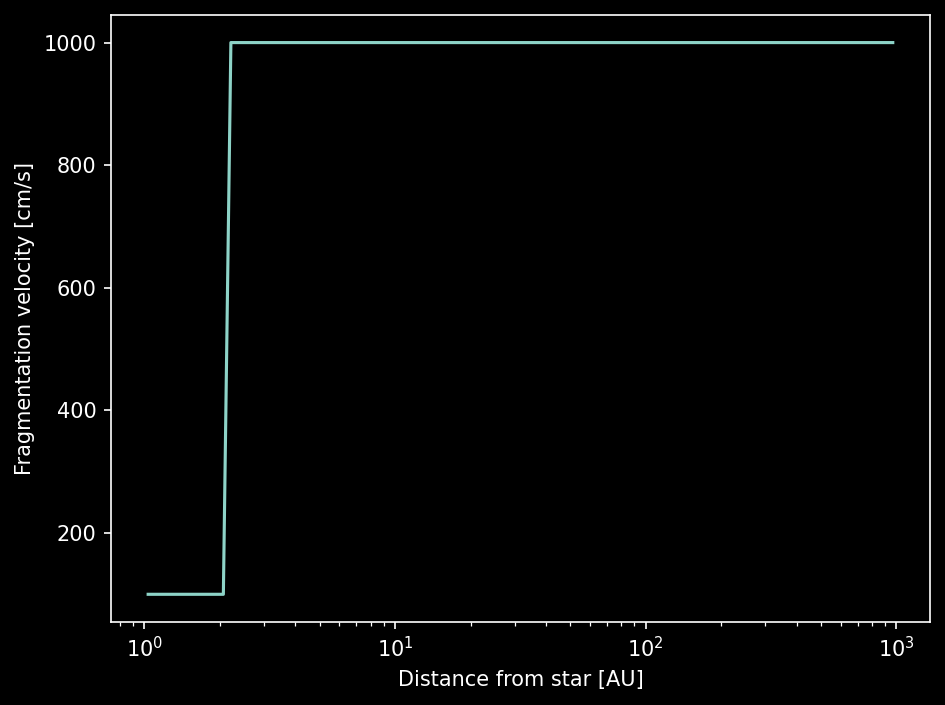

In [101]:
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111)
ax.semilogx(sim.grid.r/c.au, sim.dust.v.frag)
ax.set_xlabel("Distance from star [AU]")
ax.set_ylabel("Fragmentation velocity [cm/s]")
fig.tight_layout()
plt.show()

**Note: Upon customizing a quantity on which other quantities depend, one also has to update these quantities. In our case, this would be the sticking/fragmentation probabilites. Therefore, it is always better to update the entire simulation frame.**

In [ ]:
sim.update()

# Agregar un NUEVO Field

Sabemos que podemos modificar un Field existente, pero tripodpy permite tambien agregar nuevos campos (Fields). La consigna en este caso sería crear **"Distancia del snowline"** (`rsnow`) a `sim.grid`.

Primero, debemos inicializar nuestro nuevo Field:

In [109]:
sim.grid.addfield?

Signature:
sim.grid.addfield(
    name,
    value,
    updater=None,
    differentiator=None,
    description='',
    constant=False,
    save=True,
    copy=True,
)
Docstring:
Function to add a new ``Field`` to the object.

Parameters
----------
name : string
    Name of the field
value : number, array, string
    Initial value of the field. Needs to have already the correct type and shape
updater : Heartbeat, Updater, callable or None, optional, default : None
    Updater for field update
differentiator : Heartbeat, Updater, callable or None, optional, default : None
    Differentiator if the field has a derivative
description : string, optional, default : ""
    Descriptive string for the field
constant : boolean, optional, default : False
    True if the field is immutable
save : boolean, optional, default : True
    If True field will be stored in output files
copy : boolean, optional, default : True
    If True <value> will be copied, not referenced
File:      c:\astro\tripodpy\e

In [110]:
sim.grid.addfield("rsnow", 0. , description="Snowline Location [cm]")


In [111]:
sim.grid

Group (Grid quantities)
-----------------------
    A            : Field (Radial grid annulus area [cm²]), constant
    Nr           : Field (# of radial grid cells), constant
    OmegaK       : Field (Keplerian frequency [1/s])
    r            : Field (Radial grid cell centers [cm]), constant
    ri           : Field (Radial grid cell interfaces [cm]), constant
    rsnow        : Field (Snowline Location [cm])
  -----

Definimos que la linea de hielo debe estar donde `sim.gas.T` sea menor a 150K. Por lo tanto la siguiente funcion seria clave:

In [112]:
def rsnow(sim):
    isnow = np.argmax(sim.gas.T<150.)
    return sim.grid.ri[isnow]

In [114]:
sim.grid.rsnow.updater.updater = rsnow

In [115]:
sim.grid.rsnow.update()

In [116]:
print("The snowline is located at {:4.2f} AU.".format(sim.grid.rsnow/c.au))


The snowline is located at 2.14 AU.


Obviamente el snowline no varia en r, ya que la temperatura en el disco es constante, esto se debe a que las propiedades de la estrella permanecen constantes. Necesitamos que el perfil de temparuta cambie, pero ya vimos en el notebook de `personalizacion.ipynb` que los parametros de `sim.star.R` y `sim.star.T` cambian el perfil de temperatura. Por lo que se nos podria ocurrir que el radio de la estrella cambie de manera drastica para ver como evoluciona el snowline.

Para esto hagamos que el radio de la estrella disminuya de $3 M_\odot$ a $2 M_\odot$ en los primeros 10.000 años. Como consecuencia la temperatura del disco cambiara.

In [117]:
def Rstar(sim):
    dR = -1.*c.R_sun
    dt = 1.e4 * c.year
    m = dR/dt
    R = m*sim.t + 3.*c.R_sun
    R = np.maximum(R, c.R_sun)
    return R

sim.star.R.updater.updater = Rstar


# Orden de los Update() (*Y Como modificarlo*)

**Esto no es suficiente para que todo funcione,** le hemos dicho a `TwoPopPy` como se hace, pero no como se actualiza.

`TwoPopPy` llama a `Simulation.update()` en cada paso de tiempo, luego del paso de integracion/calculo y antes de cada vez que se escribe data. El updater de un grupo/lista es literalmente una lista con el orden de ese orden. Ejemplo a continuacion:

In [118]:
sim.updateorder

['star', 'grid', 'components', 'gas', 'dust']

In [119]:
sim.grid.updateorder

['OmegaK']

In [141]:
sim.gas.updateorder

['Sigma',
 'mu',
 'T',
 'alpha',
 'cs',
 'Hp',
 'nu',
 'rho',
 'n',
 'mfp',
 'P',
 'eta',
 'torque',
 'S']

In [144]:
sim.gas.S.updateorder

['ext', 'tot']

In [143]:

sim.gas.v.updateorder


['visc', 'rad']

In [142]:
sim.dust.updateorder

['delta',
 'rhos',
 'fill',
 'backreaction',
 'f',
 'qrec',
 'a',
 'm',
 'St',
 'H',
 'rho',
 'D',
 'eps',
 'v',
 'p',
 'q',
 'SigmaFloor',
 'S']

**Nota:** Se aprecia que hay ciertos updater() que no se realizan dentro del grupo principal, esto se debe a que se hace una derivacion implicita al final de cada integracion. Ver documentacion sec. 3 para más info.

Ahora tambien notamos que rsnow no esta en el `.grid.updateorder()` por lo que simplemente lo agregamos.

In [145]:
sim.grid.updater = ["OmegaK", "rsnow"]


In [146]:
sim.grid.updateorder

['OmegaK', 'rsnow']

Ahora, tenemos un *Error conceptual*, esto se debe en el `sim.updateorder()` el orden de update es primero grid->gas, por lo que siempre tendriamos la linea de hielo de la snapshot anterior. Ademas no podemos alterar el orden de integracion ya que el gas necesita de la frecuencia kepleriana para sus calculos $\Omega_K$. Esto se puede solucionar utilizando los `Systoles` y `Diastoles` de cada `Updater`. 

Primero que nada, revertimos el `updateorder` del grid.

In [147]:
sim.grid.updater = ["OmegaK"]

Como sabemos cada updater tiene un `Systole` y un `Diastole`. Estas son funciones que son llamadas antes y despues de updater actual. Como ninguna otra componente depende del snownline, simplemente podemos actualizarlo al final y ubicarlo en el `Diastole` del updater principal. 

Si queremos ser mas especificos y podrian haber mas pasos intermediaraios, podemos agregarlo al `Diastole` de la temperatura del gas. Ya que solo requiere la "nueva" temperatura.

In [148]:
def diastole(sim):
    sim.grid.rsnow.update()

In [149]:
sim.gas.T.updater.diastole = diastole


In [150]:
sim.t.snapshots = np.logspace(3., 4., num=21, base=10.) * c.year
sim.writer.datadir = "3_data"
sim.run()



tripodpy v1.0.0

Creating data directory 3_data.
Writing file 3_data\data0000.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0001.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0002.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0003.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0004.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0005.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0006.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0007.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0008.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0009.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0010.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0011.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0012.hdf5
Writing dump file 3_data\frame.dmp
Writing file 3_data\data0013.hdf5
Writing dump file 3

In [3]:
from tripodpy import plot


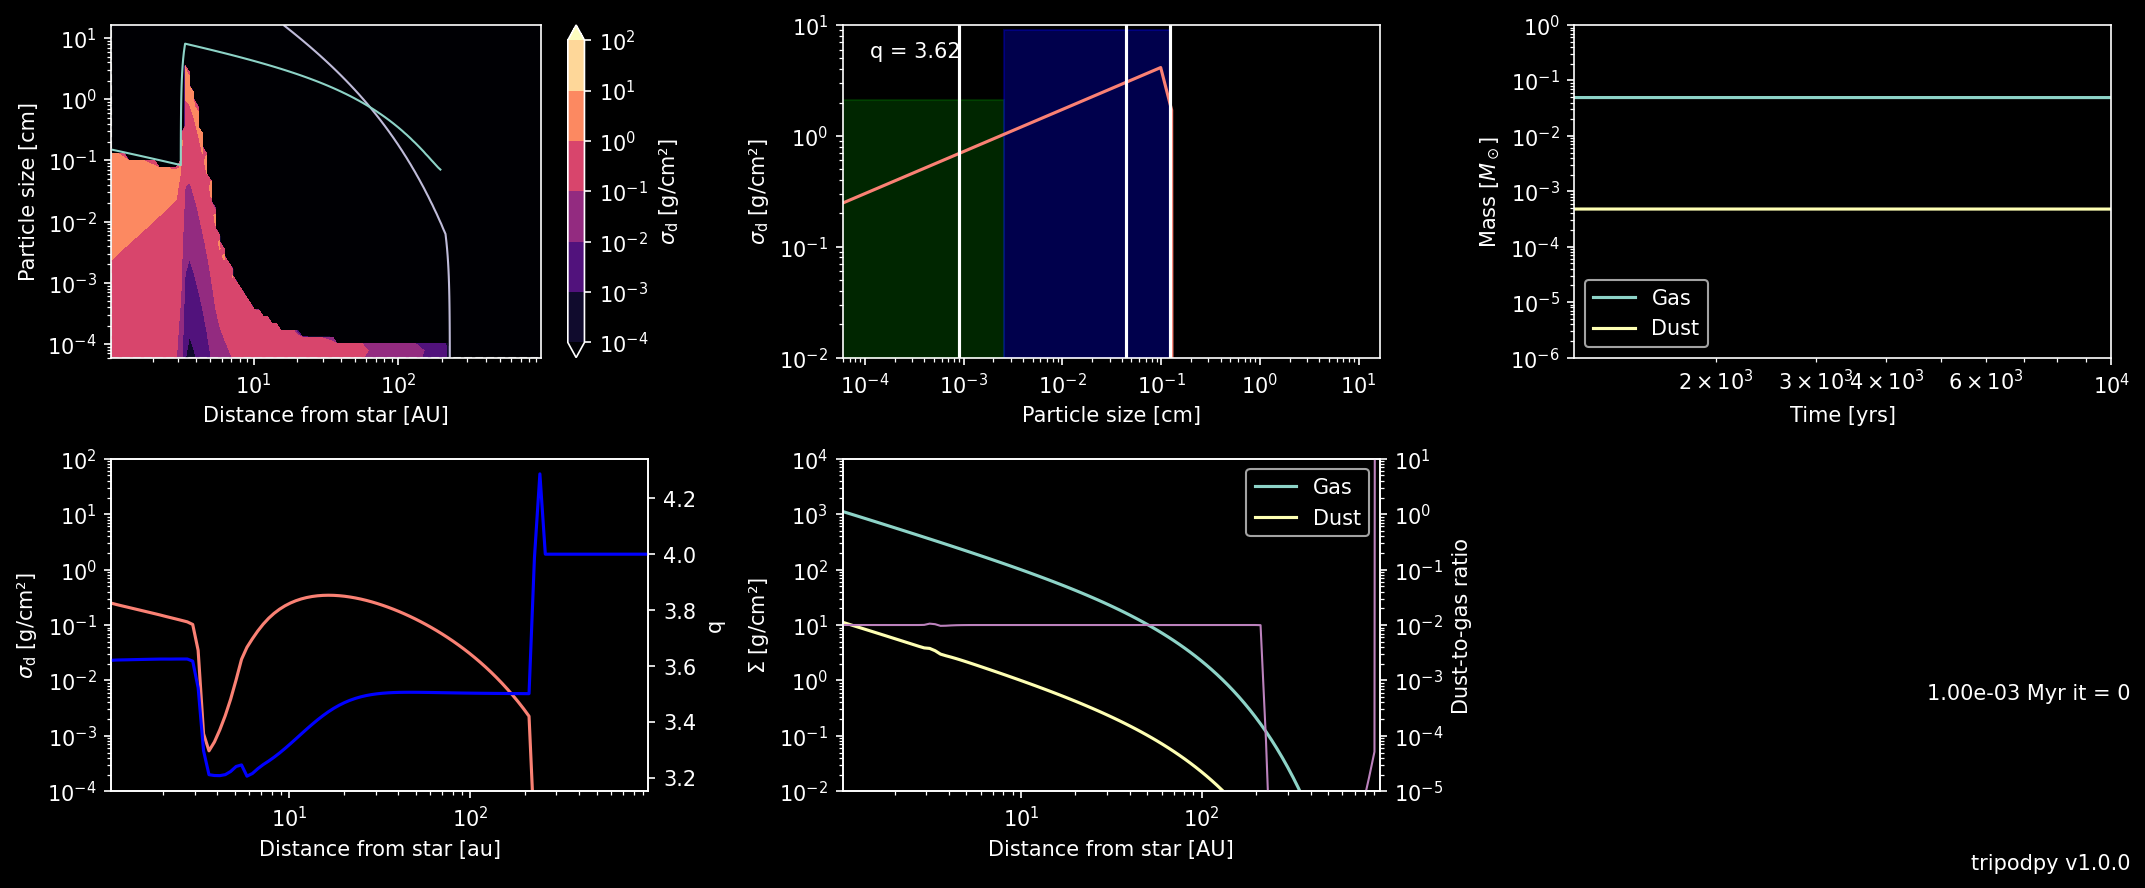

In [8]:
plot.panel(data="3_data")

In [ ]:
from dustpy import hdf5writer

wrtr = hdf5writer()

wrtr.datadir = "3_data"
data_w_v_frag = wrtr.read.all()

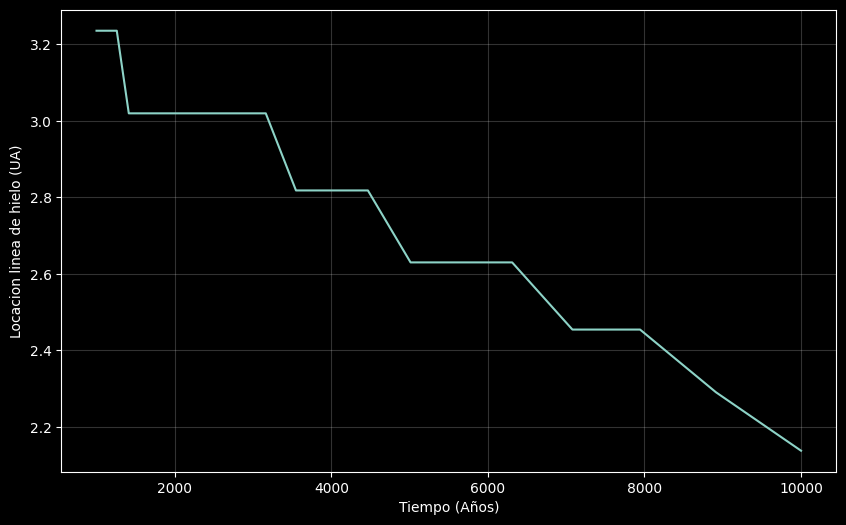

In [ ]:
import matplotlib.pyplot as plt

# Aqui ya tenemos el snowlinea agreado y deberiamos tener acceso a el

rsnowline = data_w_v_frag.grid.rsnow

rsnowline_data = rsnowline / c.au

tiempo = data_w_v_frag.t / c.year


plt.figure(figsize=(10,6))
plt.plot(tiempo, rsnowline_data)
plt.xlabel(f"Tiempo (Años)")
plt.ylabel(f"Locacion linea de hielo (UA)")
plt.grid(True, alpha = 0.2)


# Creacion de un sistema custom. Sin quimicos, pero con grilla personalizada y paremetros estelares diferentes.

Mi idea es hacer lo siguiente:

Crear un disco protoplanetrio de 0.1 - 300 UA con una evolución de 1M de años, donde exista un snowline, pero me iamgino que como el disco evoluciona, la tempepratuar evoluciona por lo que la snowline evoluciona, cierto? por lo tanto v_frag debe cambiar con el tiempo. Como v_frag, cambia con el tiempo, el gap deberia ser algo dinamico. Ese es el objetivo, que al ver la animacion de la simulacion podamos ver como evoluciona.

Me acabo de dar cuenta que la forma en la que definimos antes el v_frag ya es dinmaico, ya que el polvo tambien es dinamico.


Lo que hare no es eso, variaremos las varibels estelares simplemente y no hare eso de los snowlines, pero en otra ocacion lo haremos.



In [2]:
from tripodpy import Simulation
from tripodpy import plot
import dustpy.constants as c
import numpy as np

In [8]:
sim = Simulation()

ri = np.logspace(-1., 3., num=51, base=10 )
# No vamos a modificar la grilla mas alla de modificar el ri.

In [14]:
sim.grid.ri = ri

# Ahora tenemos el ri listo, inicializamos la grilla

sim.makegrids()

In [22]:
# Tenemos la grilla lista, pero ahora queremos actualizar el updater de v_frag para modificarlo en cada step de la simulacion
# Pero primero debemos inicializar todo el objeto porque no estan definidas las estructuraas de los datos
sim.dust.v

Group (Velocities)
------------------
    rel          : Group (Relative velocities)
  -----
    driftmax     : NoneType
    frag         : NoneType
    rad          : NoneType
    rad_flux     : NoneType
  -----

In [ ]:
sim.initialize()

In [26]:
# De momento todo constante
sim.dust.v.frag

[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100.]

In [32]:
sim.dust.v.frag.updater.updater

Updater
-------

Type: NoneType

In [35]:
def v_frag_variable(sim):
    return np.where(sim.gas.T<150, 1000., 100.)


# Pebble Accretion 3 (PA3Py)

Este módulo es una evolución algorítmica de `PebbleAccretion2.py` que integra estricta y directamente las formulaciones físicas obtenidas en:
- **Ormel (2017)**: *The Emerging Paradigm of Pebble Accretion*.
- **Drążkowska et al. (2023)**: *Planet Formation Theory in the Era of ALMA and Kepler: from Pebbles to Exoplanets*.

## Diferencias Clave con Versiones Anteriores

La arquitectura general del código (carga robusta y unificada de los HDF5 generados por `tripodpy` vía `from_datadir()`) se mantiene idéntica para asegurar total compatibilidad cruzada con el pipeline de evolución física, limitando exclusivamente los cambios a las fórmulas de régimen y cortes analíticos numéricamente evaluados.

### 1. Masa Crítica para iniciar la Acreción de Pebbles (*Onset Mass*)
Aparece una exclusión física para los cuerpos muy livianos. Para poder capturar el gas necesario de arrastre, un cuerpo debe tener una masa mínima. Implementamos:
$$ M_{\rm PA\ onset} = {\rm St} \eta^3 M_{\star} $$

*Implementación:* Si $M_{\rm pl} < M_{\rm PA\ onset}$, el modelo no asume tasa nula, sino que cruza al modo de **Acreción de Planetesimales (Safronov)** (Ec. 7.14 de Ormel 2017), asumiendo régimen gas-free balístico bajo densidad propia rocosa. Esto produce que haya una transición real entre el crecimiento primigenio de embriones pequeños al runaway estrepitoso provisto por pebbles.

### 2. Ecuaciones Dinámicas de Acreción
Se dividen orgánicamente los regímenes del acercamiento orbital según las propiedades fluidas analizadas por **Ormel (2017)**. 
- **Headwind (Bondi-like drift limit)** ($M \lesssim M_{\rm hw/sh}$):
  $$ \dot{M}_{\rm 2D, hw} = \sqrt{8 G M_{\rm pl} t_{\rm stop} v_{\rm hw}} \Sigma_{\rm peb} $$
- **Shear (Hill limit)** ($M \gtrsim M_{\rm hw/sh}$):
  $$ \dot{M}_{\rm 2D, sh} = 2 R_{\rm Hill}^2 \Omega_{\rm K} {\rm St}^{2/3} \Sigma_{\rm peb} $$
  
Con la masa de transición evaludaba matemáticamente con:
$$ M_{\rm hw/sh} = \frac{v_{\rm hw}^3}{8 G \Omega_{\rm K} t_{\rm stop}} $$

### 3. Transición Analítica a disco Extenso 3D
Ya no se evalúa `erf` numéricamente para forzar transiciones. Se utiliza la aproximación turbulenta del factor de decaimiento natural propuesta por **Dubrulle (1995) / Ormel 2017 (Eq 7.24)**:
$$ \dot{M} = \dot{M}_{\rm 2D} \left( \frac{b_{\rm col}}{b_{\rm col} + h_{\rm peb} \sqrt{8/\pi}} \right) $$
Donde $h_{\rm peb} = \sqrt{\frac{\alpha_T}{\alpha_T + {\rm St}}} h_{\rm gas}$. Esta transición converge al límite 3D natural en discos muy agitados verticalmente.

### 4. Masa Reguladora de Aislamiento
Las barreras numéricas y el *overshoot* quedan protegidos por el rediseño más actualizado sobre retroalimentación entre aislamiento del gap y gas proporcionado por Bitsch, modificado bajo la última simplificación analítica de la comparación de **Drążkowska et al. 2023**:
$$ M_{\rm iso, peb} = 25 M_{\oplus} \left(\frac{H/r}{0.05}\right)^3 \left(\frac{M_{\star}}{M_{\odot}}\right) $$

### 5. Consumo y Drift
Los Pebbles viajan hacia la estrella limitados por:
$$ v_{\rm r,solid} \approx \frac{- 2\eta v_{\rm K} {\rm St}}{1 + {\rm St}^2} $$
Para mantener el módulo de acreción puramente parasitario y conservador, se extrae la traza dinámica de `tripodpy` asumiendo compatibilidad directa, validando los cruces del disco para compartir eficientemente los flujos con el acercamiento analógico del bucle espacial y temporal.

## Limitaciones y Notas Computacionales

- Para hacer cross-checking de perfiles puedes lanzar copias modulares intercambiando la clase originaria.
- El objeto instanciado expone un método llamado `.summary(results)` idéntico para que todo log del pipeline mantenga retrocompatibilidad.
